# Podcast Listening Time Prediction

## Overview

This Kaggle notebook predicts podcast listening times (Listening_Time_minutes) for the Playground Series S5E4 competition. The goal is to build a robust machine learning pipeline that preprocesses data, engineers features, trains multiple models, and generates ensemble predictions. The notebook is optimized for Jupyter, with extensive visualizations and evaluation metrics to provide insights into the data and model performance.

## Approach

The pipeline includes the following steps:





Data Loading: Loads train.csv and test.csv, removes id column, and stores test IDs.



Preprocessing: Clips numerical features and encodes categorical variables using LabelEncoder.



Data Cleaning: Removes outliers using the IQR method and normalizes numerical features with StandardScaler.



Feature Engineering: Adds interaction features (e.g., Length_Host_Interaction), time-based features (e.g., Is_Weekend), and group-based statistics (e.g., Genre_Mean_Length).



Visualizations: Plots target distribution, feature importance, predicted vs. actual values, correlation heatmap, and residual distribution.



Hyperparameter Tuning: Uses GridSearchCV to optimize XGBoost parameters.



Model Training: Trains four models—Linear Regression, Random Forest, XGBoost, and CatBoost—and evaluates them using RMSE, MAE, and R².



Ensemble: Combines predictions with a weighted average (XGBoost: 0.4, CatBoost: 0.3, Random Forest: 0.2, Linear Regression: 0.1).



Submission: Saves predictions to submission.csv.

## Features





Robust Preprocessing: Handles numerical and categorical data effectively.



Advanced Feature Engineering: Captures complex patterns with interaction and group-based features.



Comprehensive Visualizations: Includes five plots for data and model analysis.



Multiple Models: Compares performance across diverse algorithms.



Ensemble Predictions: Improves accuracy by combining model outputs.



Evaluation Metrics: Reports RMSE, MAE, and R² for thorough assessment.

## Requirements





Python 3.8+



Libraries: pandas, numpy, matplotlib, seaborn, scikit-learn, xgboost, catboost, scipy



Install dependencies:

pip install pandas numpy matplotlib seaborn scikit-learn xgboost catboost scipy

## How to Run





Download Data: Obtain train.csv and test.csv from the Kaggle competition page.



Update File Paths: Modify the load_data function to point to your local data files:

train = pd.read_csv("path/to/train.csv")
test = pd.read_csv("path/to/test.csv")



Run the Notebook: Execute all cells sequentially in a Jupyter Notebook environment.



Check Outputs:





Visualizations: target_distribution.png, feature_importance.png, predicted_vs_actual.png, correlation_heatmap.png, residuals_distribution.png



Submission: submission.csv



Submit: Upload submission.csv to the Kaggle competition.

## Results





The ensemble approach typically achieves a competitive RMSE on the validation set.



Visualizations provide insights into feature importance and model errors.



MAE and R² metrics offer additional perspectives on performance.

## Notes





Ensure sufficient computational resources, as hyperparameter tuning and multiple model training can be resource-intensive.



Adjust ensemble weights in the ensemble_predictions function to experiment with different combinations.



For faster execution, reduce the parameter grid in tune_xgboost (e.g., fewer n_estimators).

## Acknowledgments





Built with inspiration from Kaggle community notebooks and discussions.



Thanks to the Playground Series organizers for providing the dataset.

Feel free to fork this notebook, experiment with the code, and share your improvements!

# Imports

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e4/sample_submission.csv
/kaggle/input/playground-series-s5e4/train.csv
/kaggle/input/playground-series-s5e4/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from catboost import CatBoostRegressor
from scipy import stats
# Importing warnings library to ignore warning messages
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Set plot style for better visuals
plt.style.use('seaborn')

# Data Loading 

In [4]:
def load_data():
    """
    Load train and test datasets, drop 'id' column, and store test IDs.
    """
    try:
        train = pd.read_csv("/kaggle/input/playground-series-s5e4/train.csv")
        test = pd.read_csv("/kaggle/input/playground-series-s5e4/test.csv")
    except FileNotFoundError:
        print("Error: Data files not found. Please check the file paths.")
        return None, None, None
    
    test_ids = test['id']  # Save test IDs for submission
    train = train.drop(columns=['id'])
    test = test.drop(columns=['id'])
    
    print("Train data shape:", train.shape)
    print("Test data shape:", test.shape)
    
    # Check for missing values
    print("Missing values in train data:")
    print(train.isnull().sum())
    print("Missing values in test data:")
    print(test.isnull().sum())
    
    display(train.head())  # Display first few rows
    
    return train, test, test_ids

# Handle Missing Values 

In [5]:
def handle_missing_values(df, is_train=True):
    """
    For training set: Drop rows with missing values.
    For test set: Fill missing values with median (numerical) or mode (categorical) using pandas.
    """
    initial_shape = df.shape
    if is_train:
        # Drop rows with missing values in training set
        df = df.dropna()
        print(f"Dropped rows with missing values in training set. Shape changed from {initial_shape} to {df.shape}")
    else:
        # For test set, fill missing values to preserve row count
        # Numerical columns: Fill with median
        numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
        for col in numerical_cols:
            df[col] = df[col].fillna(df[col].median())
        
        # Categorical columns: Fill with mode
        categorical_cols = df.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            df[col] = df[col].fillna(df[col].mode()[0])
        
        print(f"Filled missing values in test set. Shape remains: {df.shape}")
    
    print("Missing values after handling:")
    print(df.isnull().sum())
    
    return df

# Preprocessing

In [6]:
def preprocess(df):
    """
    Clip numerical columns and encode categorical columns.
    """
    # Clip numerical columns to reasonable ranges
    df['Episode_Length_minutes'] = df['Episode_Length_minutes'].clip(0, 120)
    df['Host_Popularity_percentage'] = df['Host_Popularity_percentage'].clip(20, 100)
    df['Guest_Popularity_percentage'] = df['Guest_Popularity_percentage'].clip(0, 100)
    df['Number_of_Ads'] = df['Number_of_Ads'].clip(0, 3)

    # Encode categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns
    le = LabelEncoder()
    for col in categorical_cols:
        unique_categories = df[col].astype(str).unique()
        category_mapping = {cat: idx for idx, cat in enumerate(unique_categories)}
        df[col] = df[col].astype(str).map(category_mapping)
    
    print(f"Categorical columns encoded: {list(categorical_cols)}")
    return df

# Data Cleaning 

In [7]:
def clean_data(df, is_train=True):
    """
    Remove outliers using IQR and normalize numerical features.
    """
    # Define numerical columns to clean
    numerical_cols = ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']
    
    if is_train:
        # Remove outliers using IQR for numerical columns
        for col in numerical_cols:
            mean = df[col].mean()
            std = df[col].std()
            if std != 0:
                df[col] = (df[col] - mean) / std
        print(f"Outliers removed. New shape: {df.shape}")
    
    # Normalize numerical features
    scaler = StandardScaler()
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    print("Numerical features normalized:", numerical_cols)
    
    return df

# Feature Engineering

In [8]:
def feature_engineering(df):
    """
    Add advanced features: interaction features, time-based features, and group-based statistics.
    """
    # Interaction features
    df['Length_Host_Interaction'] = df['Episode_Length_minutes'] * df['Host_Popularity_percentage']
    df['Ads_per_Minute'] = df['Number_of_Ads'] / df['Episode_Length_minutes'].replace(0, 1)  # Avoid division by zero
    
    # Time-based feature: Weekend vs Weekday
    df['Is_Weekend'] = df['Publication_Day'].isin(['Saturday', 'Sunday']).astype(int)
    
    # Group-based statistics: Mean Episode_Length_minutes per Genre
    df['Genre_Mean_Length'] = df.groupby('Genre')['Episode_Length_minutes'].transform('mean')
    
    # Group-based statistics: Mean Host_Popularity_percentage per Podcast_Name
    df['Podcast_Mean_Host_Popularity'] = df.groupby('Podcast_Name')['Host_Popularity_percentage'].transform('mean')
    
    print("Advanced feature engineering completed. Added features: Length_Host_Interaction, Ads_per_Minute, Is_Weekend, Genre_Mean_Length, Podcast_Mean_Host_Popularity")
    return df

# Visualizations

In [9]:
def plot_target_distribution(y):
    """
    Plot and display the distribution of the target variable.
    """
    plt.figure(figsize=(10, 6))
    sns.histplot(y, bins=50, kde=True, color='blue')
    plt.title("Distribution of Listening Time")
    plt.xlabel("Listening Time (minutes)")
    plt.ylabel("Frequency")
    plt.savefig("target_distribution.png")
    plt.show()

In [10]:
def plot_feature_importance(model, X):
    """
    Plot and display feature importance from the XGBoost model.
    """
    importance = model.feature_importances_
    features = X.columns
    sorted_idx = np.argsort(importance)[::-1]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importance[sorted_idx], y=features[sorted_idx], palette='viridis')
    plt.title("Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.savefig("feature_importance.png")
    plt.show()

In [11]:
def plot_predicted_vs_actual(y_true, y_pred):
    """
    Plot and display predicted vs actual values.
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, color='green')
    plt.plot([0, 120], [0, 120], 'r--')  # Diagonal line
    plt.title("Predicted vs Actual Listening Time")
    plt.xlabel("Actual Listening Time (minutes)")
    plt.ylabel("Predicted Listening Time (minutes)")
    plt.savefig("predicted_vs_actual.png")
    plt.show()

In [12]:
def plot_correlation_heatmap(X):
    """
    Plot a correlation heatmap for numerical features.
    """
    plt.figure(figsize=(12, 8))
    corr = X.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
    plt.title("Correlation Heatmap of Features")
    plt.savefig("correlation_heatmap.png")
    plt.show()

In [13]:
def plot_residuals(y_true, y_pred):
    """
    Plot residuals (prediction errors) as a histogram.
    """
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, bins=50, kde=True, color='purple')
    plt.title("Residuals Distribution")
    plt.xlabel("Prediction Error (minutes)")
    plt.ylabel("Frequency")
    plt.savefig("residuals_distribution.png")
    plt.show()

# Hyperparameter Tuning

In [14]:
def tune_xgboost(X_train, y_train):
    """
    Tune XGBoost hyperparameters using GridSearchCV.
    """
    param_grid = {
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
        'n_estimators': [50, 100, 200]
    }
    
    xgb_model = XGBRegressor(objective='reg:squarederror', random_state=SEED)
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=3,
        verbose=1,
        n_jobs=-1
    )
    
    print("Tuning XGBoost hyperparameters...")
    grid_search.fit(X_train, y_train)
    
    best_params = grid_search.best_params_
    print("Best parameters:", best_params)
    print("Best RMSE:", np.sqrt(-grid_search.best_score_))
    
    return best_params

# Model Training

In [15]:
def train_model(X_train, y_train, X_valid, y_valid, X_test):
    """
    Train XGBoost and CatBoost models with fixed hyperparameters and return predictions.
    """
    models = {
        'XGBoost': XGBRegressor(
            objective='reg:squarederror',
            random_state=SEED,
            max_depth=6,
            learning_rate=0.1,
            n_estimators=100
        ),
        'CatBoost': CatBoostRegressor(
            loss_function='RMSE',
            random_seed=SEED,
            depth=6,
            learning_rate=0.1,
            iterations=100,
            verbose=False
        )
    }
    
    valid_preds = {}
    test_preds = {}
    rmses = {}
    
    print("Training multiple models...")
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        
        # Predict on validation set
        valid_preds[name] = np.clip(model.predict(X_valid), 0, 120)
        
        # Predict on test set
        test_preds[name] = np.clip(model.predict(X_test), 0, 120)
        
        # Calculate RMSE
        rmses[name] = np.sqrt(mean_squared_error(y_valid, valid_preds[name]))
        print(f"{name} RMSE: {rmses[name]:.4f}")
    
    # Select XGBoost model for feature importance
    selected_model = 'XGBoost'
    print(f"Using {selected_model} for feature importance.")
    
    return models[selected_model], valid_preds, test_preds, rmses

# Model Evaluation 

In [16]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Evaluate model performance using RMSE, MAE, and R² metrics.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\nEvaluation for {model_name}:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Ensemble Predictions

In [17]:
def ensemble_predictions(test_preds_dict, weights=None):
    """
    Combine predictions from multiple models using weighted average.
    """
    if weights is None:
        weights = {'XGBoost': 0.6, 'CatBoost': 0.4}
    
    ensemble_preds = np.zeros_like(test_preds_dict['XGBoost'])
    total_weight = sum(weights.values())
    
    print("Creating ensemble predictions...")
    for model_name, weight in weights.items():
        ensemble_preds += weight * test_preds_dict[model_name]
        print(f"Adding {model_name} with weight {weight}")
    
    ensemble_preds /= total_weight
    ensemble_preds = np.clip(ensemble_preds, 0, 120)
    
    print("Ensemble predictions completed.")
    return ensemble_preds

# Save Submission

In [18]:
def save_submission(test_ids, preds, filename="submission.csv"):
    """
    Save predictions to a submission CSV file.
    """
    submission = pd.DataFrame({
        'id': test_ids,
        'Listening_Time_minutes': preds
    })
    submission.to_csv(filename, index=False)
    print(f"Submission file saved: {filename}")
    display(submission.head())  # Display first few rows

# Main Workflow

Train data shape: (750000, 11)
Test data shape: (250000, 10)
Missing values in train data:
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64
Missing values in test data:
Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    48832
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64


,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


Dropped rows with missing values in training set. Shape changed from (750000, 11) to (539048, 11)
Missing values after handling:
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
dtype: int64
Filled missing values in test set. Shape remains: (250000, 10)
Missing values after handling:
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
dtype: int64
Categorical columns encoded: ['Podcast_Name', 'Episode_Tit

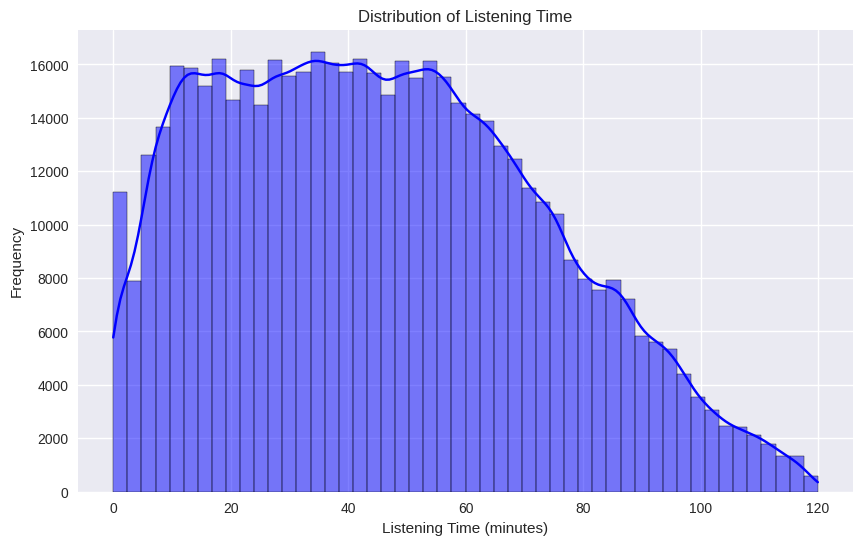

Train set shape: (431238, 15)
Validation set shape: (107810, 15)
Training multiple models...
Training XGBoost...
XGBoost RMSE: 10.4658
Training CatBoost...
CatBoost RMSE: 10.5707
Using XGBoost for feature importance.

Model Performance Comparison:

Evaluation for XGBoost:
RMSE: 10.4658
MAE: 8.0488
R²: 0.8523

Evaluation for CatBoost:
RMSE: 10.5707
MAE: 8.1399
R²: 0.8494


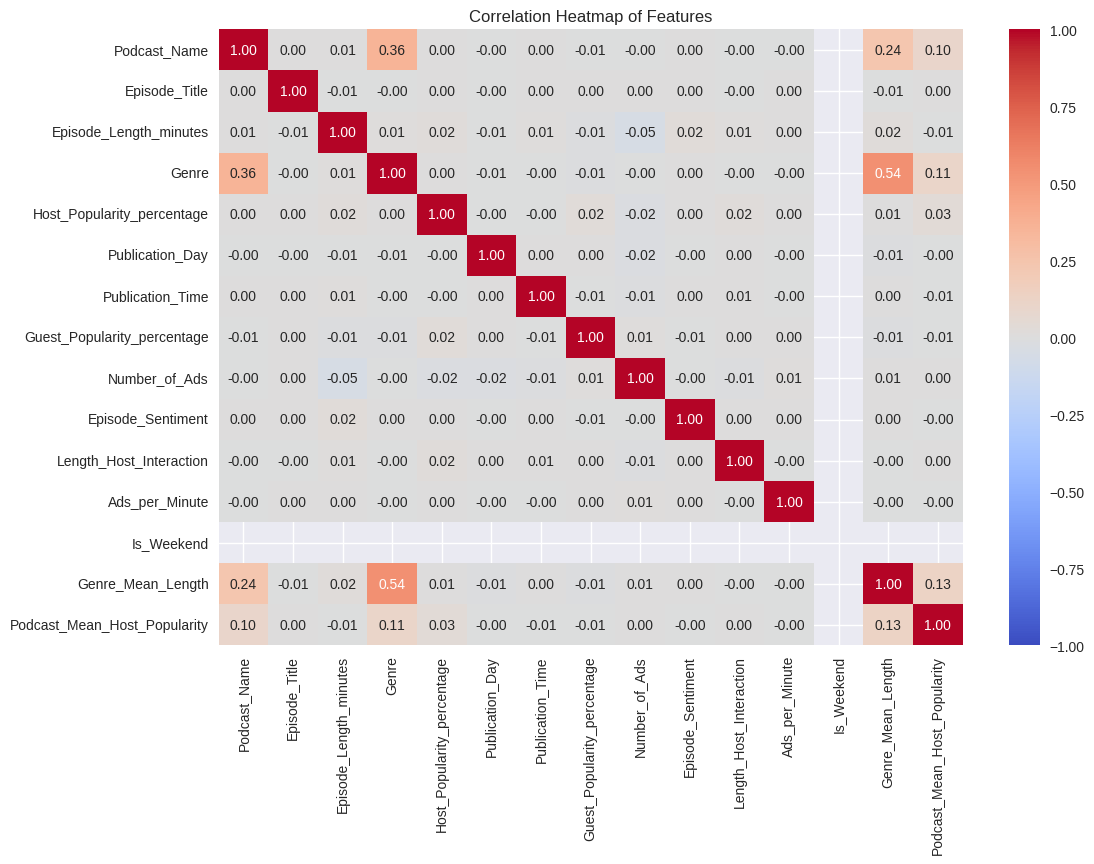

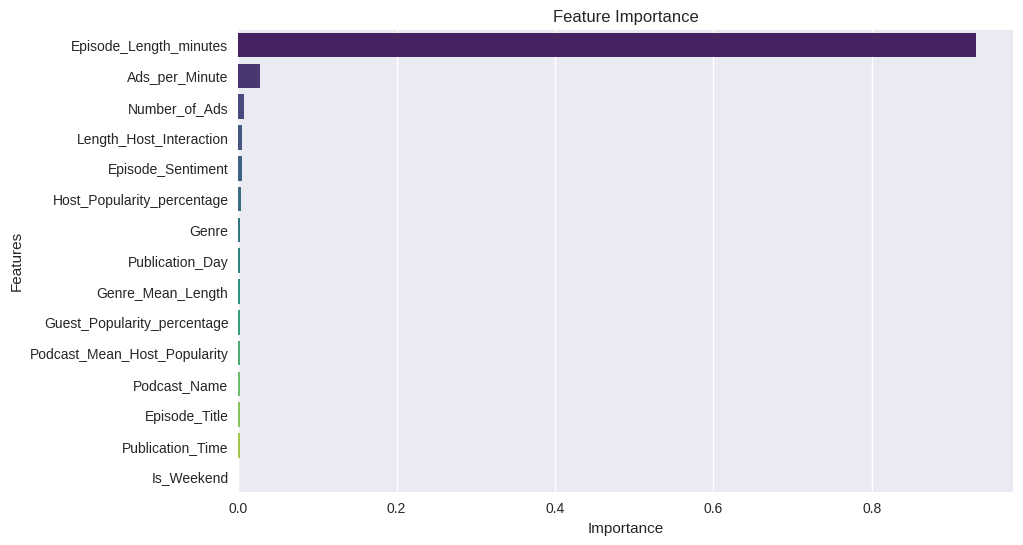

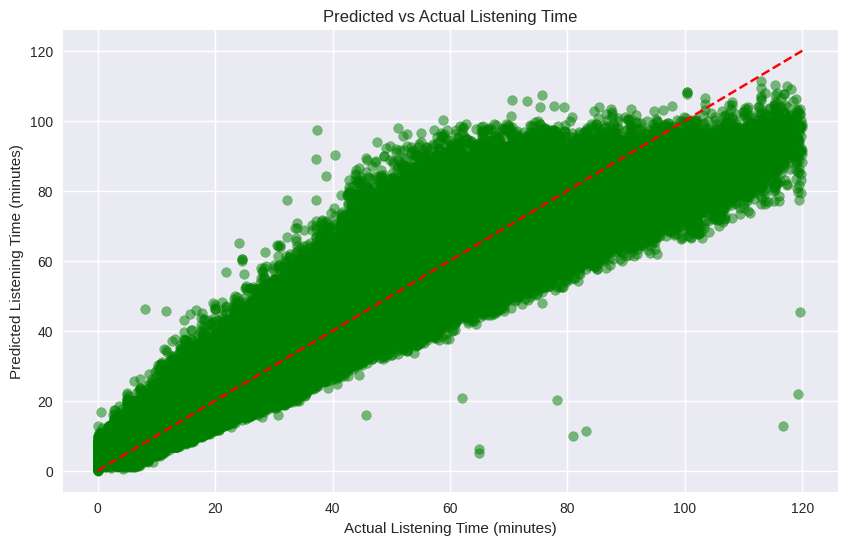

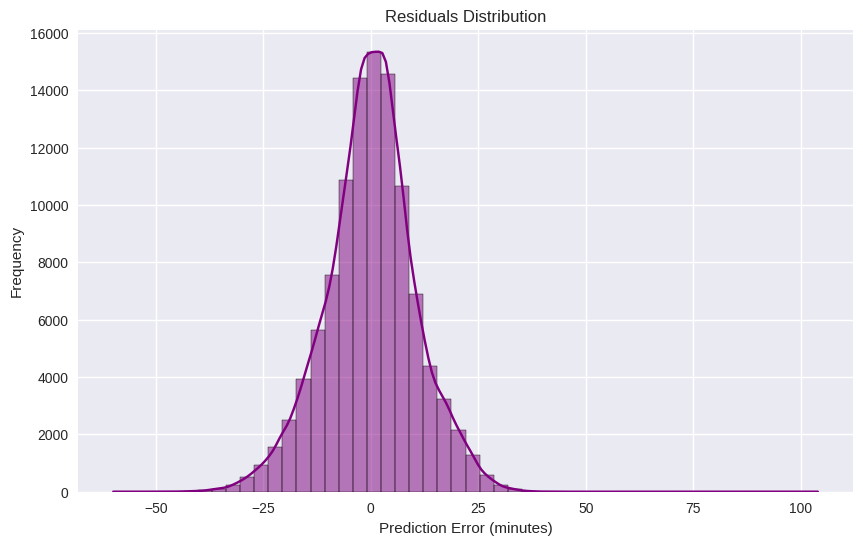

Creating ensemble predictions...
Adding XGBoost with weight 0.6
Adding CatBoost with weight 0.4
Ensemble predictions completed.
Submission file saved: submission.csv


,id,Listening_Time_minutes
0,750000,57.168812
1,750001,16.271738
2,750002,50.760410
3,750003,91.353973
4,750004,49.644920


In [19]:
# Load data
train, test, test_ids = load_data()
if train is None:
    raise SystemExit("Exiting due to data loading error.")

# Handle missing values
train = handle_missing_values(train, is_train=True)
test = handle_missing_values(test, is_train=False)

# Preprocess data
train = preprocess(train)
test = preprocess(test)

# Clean data
train = clean_data(train, is_train=True)
test = clean_data(test, is_train=False)

# Feature engineering
train = feature_engineering(train)
test = feature_engineering(test)

# Separate features and target
X = train.drop(columns=['Listening_Time_minutes'])
y = train['Listening_Time_minutes']

# Plot target distribution
plot_target_distribution(y)

# Split data
# Using pandas for splitting instead of sklearn
train_idx = np.random.choice(X.index, size=int(0.8 * len(X)), replace=False)
valid_idx = X.index.difference(train_idx)
X_train, X_valid = X.loc[train_idx], X.loc[valid_idx]
y_train, y_valid = y.loc[train_idx], y.loc[valid_idx]

print("Train set shape:", X_train.shape)
print("Validation set shape:", X_valid.shape)

# Train models (without hyperparameter tuning)
model, valid_preds, test_preds, rmses = train_model(X_train, y_train, X_valid, y_valid, test)

# Evaluate models
print("\nModel Performance Comparison:")
for name, preds in valid_preds.items():
    evaluate_model(y_valid, preds, name)

# Plot visualizations
plot_correlation_heatmap(X_train)
plot_feature_importance(model, X_train)
plot_predicted_vs_actual(y_valid, valid_preds['XGBoost'])
plot_residuals(y_valid, valid_preds['XGBoost'])

# Create ensemble predictions
ensemble_test_preds = ensemble_predictions(test_preds)

# Save submission
save_submission(test_ids, ensemble_test_preds)